In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
base_token = 0.66
global N
N = 3*base_token

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, NonlinearConstraint, Bounds, BFGS

# --------------------------------------------------
# Data Setup
# --------------------------------------------------
base_token = 0.66
N = 3 * base_token

def model(N_i, c, gamma, alpha, beta, e):
    """
    model(N_i, c, gamma, alpha, beta, e) = 
        c * (N_i + gamma*(N - 1/3*N)^alpha)^(-beta) + e
    """
    inner_term = (N - (1/3)*N)  # = 2/3*N
    return c * (N_i + gamma * (inner_term ** alpha)) ** (-beta) + e

# --------------------------------------------------
# Huber Loss
# --------------------------------------------------
def huber_loss(residuals, delta=0.001):
    """
    Standard Huber loss for a 1D array of residuals.

    Huber(r) = 0.5 * r^2       if |r| <= delta
               delta*(|r| - 0.5*delta)   otherwise
    """
    abs_r = np.abs(residuals)
    mask_quadratic = abs_r <= delta

    # If |r| <= delta => 0.5*r^2
    # Else => delta*(|r| - 0.5*delta)
    return np.where(
        mask_quadratic,
        0.5 * residuals**2,
        delta * (abs_r - 0.5 * delta),
    )

# --------------------------------------------------
# Objective: Sum of Huber Loss
# --------------------------------------------------
def objective(params, x, y):
    """
    params = [c, gamma, alpha, beta, e]
    """
    c, gamma, alpha, beta, e = params
    y_pred = model(x, c, gamma, alpha, beta, e)
    residuals = y - y_pred
    return np.sum(huber_loss(residuals, delta=0.001))

# --------------------------------------------------
# Nonlinear Constraint: gamma * (2/3*N)^alpha < (2/3*N)
# --------------------------------------------------
def constraint_fun(p):
    """
    p = [c, gamma, alpha, beta, e]
    We want: gamma * (2/3*N)^alpha - (2/3*N) < 0
             => constraint_fun(p) < 0
    """
    c, gamma, alpha, beta, e = p
    inner_term = (2.0/3.0)*N
    return gamma * (inner_term ** alpha) - inner_term

nonlinear_constraint = NonlinearConstraint(
    fun=constraint_fun,
    lb=-np.inf,
    ub=0.0,           # means constraint_fun(p) <= 0
    jac='2-point',    # finite-diff approx for constraint's Jacobian
    hess=BFGS(),      # quasi-Newton Hessian for constraint
)

# --------------------------------------------------
# Bounds (Box constraints)
# --------------------------------------------------


# bounds = Bounds(
#     lb=[1e-6, 5e-3, 0.0, 1e-5, 0.0],
#     ub=[10, 1, 0.999999, 1, 2],
# )


# bounds = Bounds(
#     lb=[1e-6, 5e-3, 0.0, 1e-5, 0.5],
#     ub=[2, 1, 0.999999, 1, 2],
# )

bounds = Bounds(
    lb=[0., 0., 0., 0., 0.],    # Lower bounds for c, gamma, alpha, beta, e
    ub=[np.inf, np.inf, np.inf, np.inf, np.inf]  # Upper bounds
)


# c, gamma, alpha, beta, e

`gtol` termination condition is satisfied.
Number of iterations: 306, function evaluations: 2340, CG iterations: 551, optimality: 1.69e-09, constraint violation: 0.00e+00, execution time: 0.67 s.
=== Optimization succeeded ===
Optimal parameters:
  c     = 0.24964708441183284
  gamma = 0.45301788264312004
  alpha = 3.7139227496659983
  beta  = 1.2436113456116562
  e     = 2.149740773704498
Objective (Sum of Huber Loss) = 3.4096220446974455e-06
0.9623735555939928


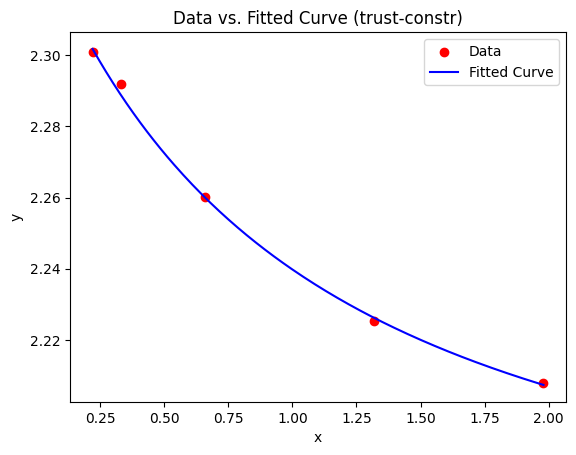

`gtol` termination condition is satisfied.
Number of iterations: 250, function evaluations: 1824, CG iterations: 480, optimality: 3.69e-09, constraint violation: 0.00e+00, execution time: 0.42 s.
=== Optimization succeeded ===
Optimal parameters:
  c     = 0.1747607571150118
  gamma = 0.48002253320744165
  alpha = 3.49530723084968
  beta  = 1.348560577081239
  e     = 2.186293624502729
Objective (Sum of Huber Loss) = 4.656029142437831e-06
0.9596892429804178


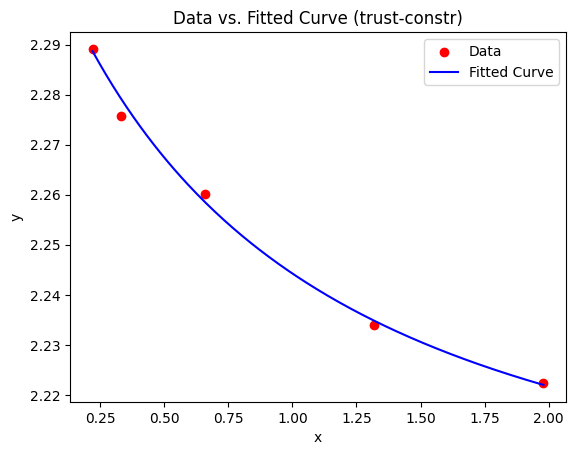

`gtol` termination condition is satisfied.
Number of iterations: 270, function evaluations: 2100, CG iterations: 486, optimality: 3.21e-09, constraint violation: 0.00e+00, execution time: 0.44 s.
=== Optimization succeeded ===
Optimal parameters:
  c     = 0.19613942967613937
  gamma = 0.45140959618553445
  alpha = 3.688254538545262
  beta  = 1.3600909191203454
  e     = 2.1786619927587614
Objective (Sum of Huber Loss) = 9.166603663139754e-07
0.952147441981699


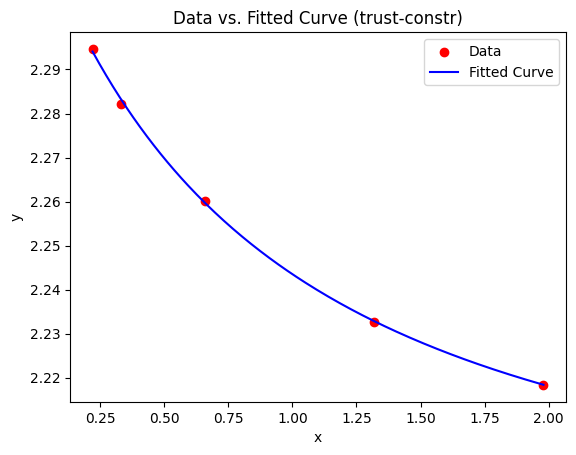

In [9]:
# --------------------------------------------------
# Optimization with method='trust-constr'
# --------------------------------------------------
initial_guess = [2.0, 0.5, 0.5, 1.0, 1.0]  # c, gamma, alpha, beta, e

x = np.array([i * base_token for i in [1/3, 1/2, 1, 2, 3]])

lyst = [
    [2.3009398127536653, 2.2919550197611414, 2.2601072040502985, 2.2253171055400482, 2.2078428253445472],
    [2.2891207768582373, 2.275715067349909, 2.2601072040502985, 2.2340252519100123, 2.2223123883020706],
    [2.2946755321189904, 2.2822197449260098, 2.2601072040502985, 2.2327336034851544, 2.2183251314478096]
]


optimized_parameters = []

for item in lyst:
    y = np.array(item)
    result = minimize(
        fun=objective,
        x0=initial_guess,
        args=(x, y),
        method='trust-constr',
        jac='2-point',  # finite-diff gradient for objective
        hess=BFGS(),    # quasi-Newton Hessian for objective
        bounds=bounds,
        constraints=[nonlinear_constraint],
        options={
            'maxiter': 50000,
            'verbose': 1,  # for debugging info
        }
    )

    # --------------------------------------------------
    # Plot & Print Results
    # --------------------------------------------------
    if result.success:
        c_opt, gamma_opt, alpha_opt, beta_opt, e_opt = result.x
        optimized_parameters.append({
            'c': c_opt,
            'gamma': gamma_opt,
            'alpha': alpha_opt,
            'beta': beta_opt,
            'e': e_opt})
        
        print("=== Optimization succeeded ===")
        print("Optimal parameters:")
        print(f"  c     = {c_opt}")
        print(f"  gamma = {gamma_opt}")
        print(f"  alpha = {alpha_opt}")
        print(f"  beta  = {beta_opt}")
        print(f"  e     = {e_opt}")
        print(f"Objective (Sum of Huber Loss) = {result.fun}")

        print((gamma_opt * ((N - (1/3)*N) ** alpha_opt))/(N - (1/3)*N))
        # Generate a smooth range of x-values to show the fitted curve
        x_fine = np.linspace(x.min(), x.max(), 200)
        y_fitted = model(x_fine, c_opt, gamma_opt, alpha_opt, beta_opt, e_opt)

        # Plot data
        plt.scatter(x, y, color='red', label='Data')
        # Plot fitted curve
        plt.plot(x_fine, y_fitted, color='blue', label='Fitted Curve')

        plt.xlabel('x')
        plt.ylabel('y')
        plt.title('Data vs. Fitted Curve (trust-constr)')
        plt.legend()
        plt.show()
    else:
        print("=== Optimization failed ===")
        print("Message:", result.message)



In [10]:
import json
with open("/mbz/users/liyuan/LLaMA-Factory/domain_weights/optimized_parameters_new.json", "w") as written_file:
    json.dump(optimized_parameters, written_file, indent=4)


In [64]:
print(10**(-0.036))
print(10**(-0.018))

print(10000**(-0.036))
print(10000**(-0.018))

0.9204495717531713
0.9594006315159331
0.7177942912713617
0.8472274141405964


In [11]:
global gamma, N, alpha
gamma=2
N = 500
alpha = 0.2

def model(w):
    return (w * N + gamma * (N - w * N) ** alpha)** (-0.5)

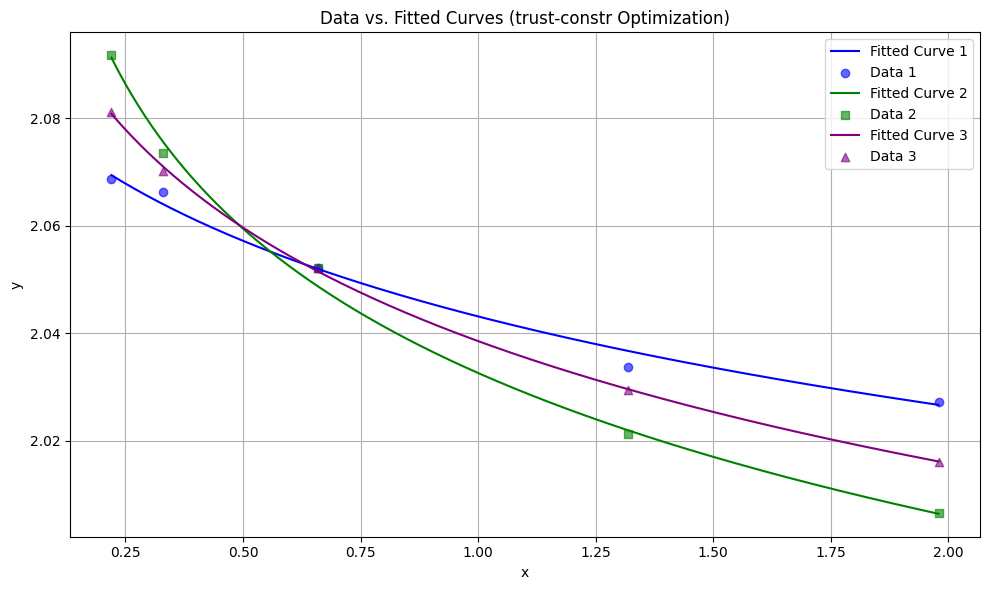

In [86]:
plt.figure(figsize=(10, 6))

colors = ['blue', 'green', 'purple']  # Colors for different curves
markers = ['o', 's', '^']  # Markers for different datasets

for idx, params in enumerate(optimized_parameters):
    c_opt = params['c']
    gamma_opt = params['gamma']
    alpha_opt = params['alpha']
    beta_opt = params['beta']
    e_opt = params['e']
    
    # Generate a smooth range of x-values for the fitted curve
    x_fine = np.linspace(x.min(), x.max(), 500)
    y_fitted = model(x_fine, c_opt, gamma_opt, alpha_opt, beta_opt, e_opt)
    
    # Plot the fitted curve
    plt.plot(x_fine, y_fitted, color=colors[idx], label=f'Fitted Curve {idx + 1}')
    
    # Optionally, plot the original data points
    y_original = np.array(lyst[idx])
    plt.scatter(x, y_original, color=colors[idx], marker=markers[idx], 
                label=f'Data {idx + 1}', alpha=0.6)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Data vs. Fitted Curves (trust-constr Optimization)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
20**(-2)

0.0025

** L-BFGS-B 

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.08787D-03    |proj g|=  6.96505D-03

At iterate    1    f=  3.02948D-03    |proj g|=  6.80807D-03

At iterate    2    f=  1.53216D-03    |proj g|=  1.33057D-03

At iterate    3    f=  1.28092D-03    |proj g|=  1.30591D-03

At iterate    4    f=  7.55396D-04    |proj g|=  1.26503D-03

At iterate    5    f=  4.69679D-04    |proj g|=  1.04883D-03

At iterate    6    f=  3.62054D-04    |proj g|=  4.54572D-03

At iterate    7    f=  1.73986D-04    |proj g|=  1.01554D-03

At iterate    8    f=  1.39414D-04    |proj g|=  1.80971D-03
  Positive dir derivative in projection 
  Using the backtracking step 

At iterate    9    f=  2.32081D-05    |proj g|=  3.26671D-03
  Positive dir derivative in projection 
  Using the backtracking step 

At iterate   10    f=  1.88066D-05    |proj g|=  8.85353D-04

=== Ro

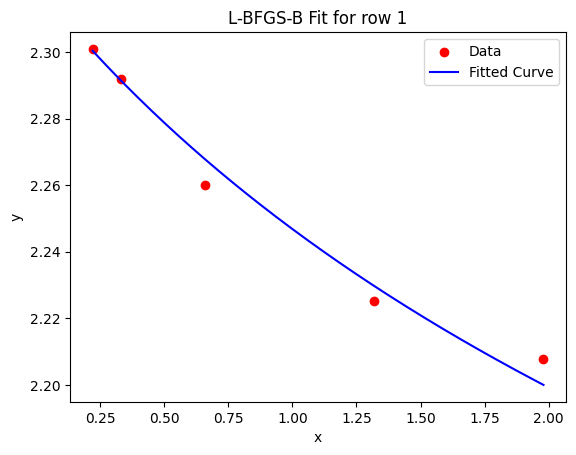

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.13910D-03    |proj g|=  6.96505D-03

At iterate    1    f=  3.08072D-03    |proj g|=  6.80807D-03

At iterate    2    f=  1.58340D-03    |proj g|=  1.33057D-03

At iterate    3    f=  1.33215D-03    |proj g|=  1.30591D-03

At iterate    4    f=  8.04287D-04    |proj g|=  1.24847D-03

At iterate    5    f=  5.20707D-04    |proj g|=  1.04865D-03

At iterate    6    f=  3.94355D-04    |proj g|=  4.85935D-03

At iterate    7    f=  1.96708D-04    |proj g|=  1.01336D-03

At iterate    8    f=  1.66293D-04    |proj g|=  1.83625D-03
  Positive dir derivative in projection 
  Using the backtracking step 

At iterate    9    f=  4.44174D-05    |proj g|=  3.84377D-03

At iterate   10    f=  2.52021D-05    |proj g|=  2.08389D-03

At iterate   11    f=  1.94604D-05    |proj g|=  3.00000D-03

At iterate   12 

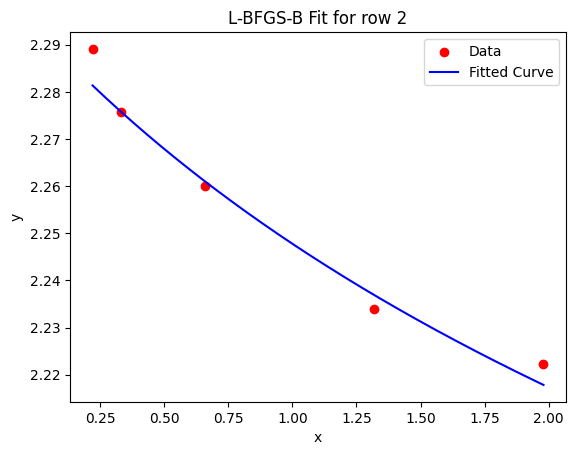

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  3.12176D-03    |proj g|=  6.96505D-03

At iterate    1    f=  3.06338D-03    |proj g|=  6.80807D-03

At iterate    2    f=  1.56606D-03    |proj g|=  1.33057D-03

At iterate    3    f=  1.31481D-03    |proj g|=  1.30591D-03

At iterate    4    f=  7.87483D-04    |proj g|=  1.25227D-03

At iterate    5    f=  5.03420D-04    |proj g|=  1.04869D-03

At iterate    6    f=  3.81184D-04    |proj g|=  5.14438D-03

At iterate    7    f=  1.87433D-04    |proj g|=  1.01421D-03

At iterate    8    f=  1.53247D-04    |proj g|=  1.30594D-03

At iterate    9    f=  1.53210D-04    |proj g|=  1.55332D-03
  Positive dir derivative in projection 
  Using the backtracking step 

At iterate   10    f=  3.59819D-05    |proj g|=  5.29593D-03

At iterate   11    f=  2.06928D-05    |proj g|=  3.19831D-03

At iterate   12 

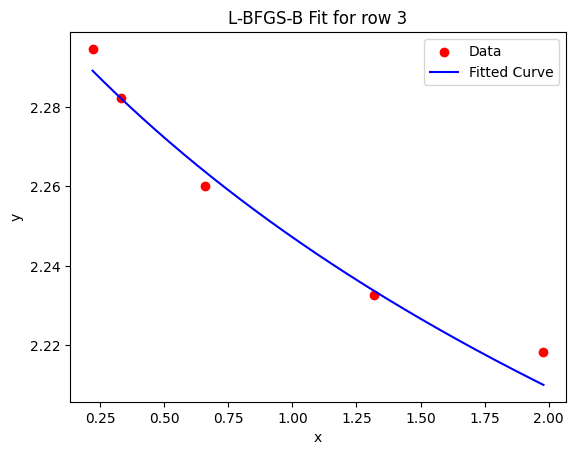


All optimized parameters: [{'c': 1.2855606414100322, 'gamma': 1.3912890974901428, 'alpha': 0.8369785004343334, 'beta': 0.14112029253082092, 'e': 1.1325797277843157}, {'c': 1.2301520616165864, 'gamma': 1.4070443445490484, 'alpha': 0.8493350488471987, 'beta': 0.0895844088555317, 'e': 1.125341909529921}, {'c': 1.2561309015820246, 'gamma': 1.419181784841925, 'alpha': 0.8490428464044857, 'beta': 0.11264496054304006, 'e': 1.1284768504163183}]


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, Bounds

# --------------------------------------------------
# Data Setup
# --------------------------------------------------
base_token = 0.66
N = 3 * base_token

# x-values
x = np.array([base_token * i for i in [1/3, 1/2, 1, 2, 3]])

# y-values in a list of lists
lyst = [
    [2.3009398127536653, 2.2919550197611414, 2.2601072040502985, 2.2253171055400482, 2.2078428253445472],
    [2.2891207768582373, 2.275715067349909, 2.2601072040502985, 2.2340252519100123, 2.2223123883020706],
    [2.2946755321189904, 2.2822197449260098, 2.2601072040502985, 2.2327336034851544, 2.2183251314478096]
]

# --------------------------------------------------
# Model
# --------------------------------------------------
def model(N_i, c, gamma, alpha, beta, e):
    """
    model(N_i, c, gamma, alpha, beta, e) = 
        c * (N_i + gamma*( (2/3)*N )^alpha )^(-beta) + e
    """
    # (N - 1/3*N) = (2/3)*N
    inner_term = (2.0/3.0) * N
    return c * (N_i + gamma * (inner_term ** alpha)) ** (-beta) + e

# --------------------------------------------------
# Huber Loss
# --------------------------------------------------
def huber_loss(residuals, delta=0.001):
    """
    Standard Huber loss for a 1D array of residuals.
    Huber(r) = 0.5 * r^2      if |r| <= delta
               delta*(|r| - 0.5*delta)   otherwise
    """
    abs_r = np.abs(residuals)
    mask_quadratic = abs_r <= delta
    return np.where(
        mask_quadratic,
        0.5 * residuals**2,
        delta * (abs_r - 0.5 * delta),
    )

# --------------------------------------------------
# Objective: Sum of Huber Loss
# --------------------------------------------------
def objective(params, x_data, y_data):
    """
    params = [c, gamma, alpha, beta, e]
    """
    c, gamma, alpha, beta, e = params
    y_pred = model(x_data, c, gamma, alpha, beta, e)
    residuals = y_data - y_pred
    return np.sum(huber_loss(residuals, delta=0.001))

# --------------------------------------------------
# Bounds: c, gamma, alpha, beta, e >= 0
# --------------------------------------------------
bounds = Bounds(lb=[0., 0., 0., 0., 0.],
                ub=[np.inf, np.inf, np.inf, np.inf, np.inf])

# --------------------------------------------------
# L-BFGS-B Optimization Loop
# --------------------------------------------------
initial_guess = [2.0, 0.5, 0.5, 1.0, 1.0]  # c, gamma, alpha, beta, e
optimized_parameters = []

for i, item in enumerate(lyst, start=1):
    y = np.array(item)  # Convert list to np.array

    result = minimize(
        fun=objective,
        x0=initial_guess,
        args=(x, y),
        method='L-BFGS-B',  # <-- L-BFGS-B here
        bounds=bounds,
        options={
            'maxiter': 50000,
            'disp': True,   # prints convergence info
        }
    )

    # --------------------------------------------------
    # Print & Plot Results
    # --------------------------------------------------
    print(f"\n=== Row {i} results ===")
    if result.success:
        c_opt, gamma_opt, alpha_opt, beta_opt, e_opt = result.x
        optimized_parameters.append({
            'c': c_opt,
            'gamma': gamma_opt,
            'alpha': alpha_opt,
            'beta': beta_opt,
            'e': e_opt
        })
        
        print("Optimization succeeded.")
        print("Optimal parameters:")
        print(f"  c     = {c_opt}")
        print(f"  gamma = {gamma_opt}")
        print(f"  alpha = {alpha_opt}")
        print(f"  beta  = {beta_opt}")
        print(f"  e     = {e_opt}")
        print(f"Objective (Sum of Huber Loss) = {result.fun}")

        # Plot the fitted curve vs. the data
        x_fine = np.linspace(x.min(), x.max(), 200)
        y_fitted = model(x_fine, c_opt, gamma_opt, alpha_opt, beta_opt, e_opt)

        plt.figure()
        plt.scatter(x, y, color='red', label='Data')
        plt.plot(x_fine, y_fitted, color='blue', label='Fitted Curve')
        plt.xlabel('x')
        plt.ylabel('y')
        plt.title(f'L-BFGS-B Fit for row {i}')
        plt.legend()
        plt.show()
    else:
        print("Optimization failed.")
        print("Message:", result.message)

print("\nAll optimized parameters:", optimized_parameters)


In [ ]:
[{'c': 1.2855606414100322, 'gamma': 1.3912890974901428, 'alpha': 0.8369785004343334, 'beta': 0.14112029253082092, 'e': 1.1325797277843157}, 
 {'c': 1.2301520616165864, 'gamma': 1.4070443445490484, 'alpha': 0.8493350488471987, 'beta': 0.0895844088555317, 'e': 1.125341909529921}, 
 {'c': 1.2561309015820246, 'gamma': 1.419181784841925, 'alpha': 0.8490428464044857, 'beta': 0.11264496054304006, 'e': 1.1284768504163183}]

In [1]:
1e6

1000000.0